In [1]:
# ============================================
# Phase 2 — Day 10: Binary Images & Morphology
# Segmentation, geometric properties, morphological ops
# ============================================

import cv2 
import numpy as np 
import matplotlib.pyplot as plt 

#load and threshold our test image to get binary 
img = cv2.imread('/home/arpeetpadhy/test_image.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, binary = cv2.threshold(gray ,50, 255, cv2.THRESH_BINARY)

print("Image loaded and converted to binary!")
print("Binary unique values:", np.unique(binary))
print("Shape:", binary.shape)

Image loaded and converted to binary!
Binary unique values: [  0 255]
Shape: (300, 300)


Number of contours found: 3

--- Geometric properties ---

Contour 1:
  Area: 9801.0 px²
  Perimeter: 396.0 px
  Bounding box: x=50, y=160, w=100, h=100
  Centroid: (99, 209)

Contour 2:
  Area: 9801.0 px²
  Perimeter: 396.0 px
  Bounding box: x=160, y=50, w=100, h=100
  Centroid: (209, 99)

Contour 3:
  Area: 9801.0 px²
  Perimeter: 396.0 px
  Bounding box: x=50, y=50, w=100, h=100
  Centroid: (99, 99)


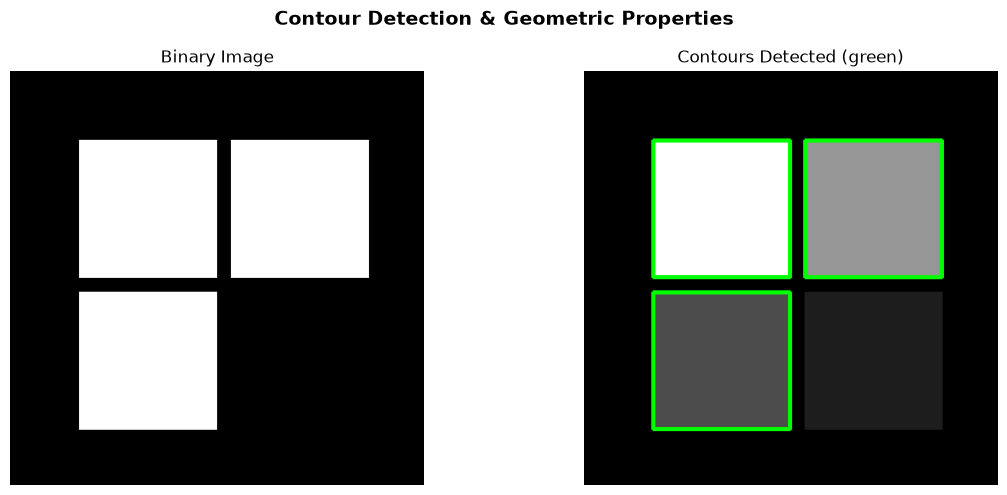

In [2]:
# ============================================
# CONTOUR DETECTION & GEOMETRIC PROPERTIES
# ============================================

# Find contours — outlines of white regions in binary image
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Number of contours found: {len(contours)}")

# Draw countour on a copy of the image 
img_contour = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.drawContours(img_contour, contours, -1, (0,255 ,0),2)

# Analyze geometric properties of each contour
print("\n--- Geometric properties ---")
for i , cnt in enumerate(contours):
    #area 
    area = cv2.contourArea(cnt)

    # perimeter 
    perimeter = cv2.arcLength(cnt, True)

    # Bounding Box 
    x,y,w,h = cv2.boundingRect(cnt)

    # Centroid (center of mass)
    M  = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx ,cy = 0,0 

    print(f"\nContour {i+1}:")
    print(f"  Area: {area} px²")
    print(f"  Perimeter: {round(perimeter, 2)} px")
    print(f"  Bounding box: x={x}, y={y}, w={w}, h={h}")
    print(f"  Centroid: ({cx}, {cy})")

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Binary Image')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_contour, cv2.COLOR_BGR2RGB))
axes[1].set_title('Contours Detected (green)')
axes[1].axis('off')

plt.suptitle('Contour Detection & Geometric Properties', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()    

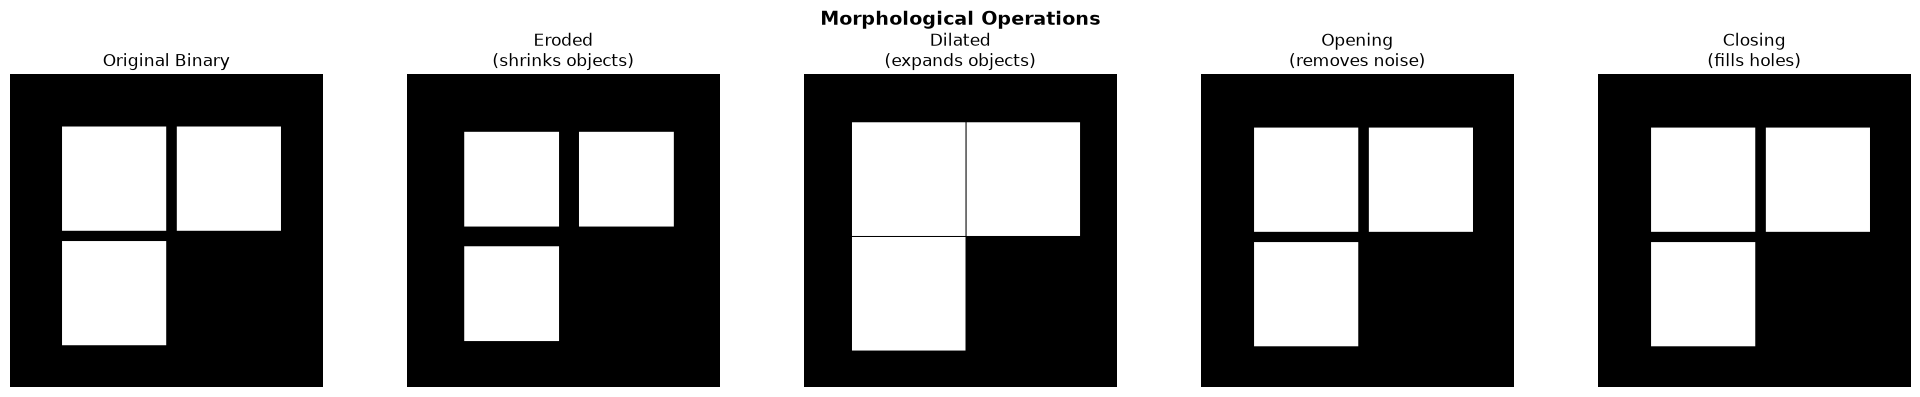

In [6]:
# ============================================
# MORPHOLOGICAL OPERATIONS
# ============================================

# Kernel - the structuring element (think of its as a brush )
kernel = np.ones((10,10),np.uint8)

eroded = cv2.erode(binary, kernel, iterations=1)

# Dilation — expands white regions (fills gaps)
dilated =cv2.dilate(binary, kernel, iterations = 1)

#Opening = Dilation then erosion (removes small holes)
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

# Closing = Dilation  then Erosion(fill small hole)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE , kernel)

fig, axes = plt.subplots(1, 5,figsize = (20,4))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Original Binary')
axes[0].axis('off')

axes[1].imshow(eroded, cmap='gray')
axes[1].set_title('Eroded\n(shrinks objects)')
axes[1].axis('off')

axes[2].imshow(dilated, cmap='gray')
axes[2].set_title('Dilated\n(expands objects)')
axes[2].axis('off')

axes[3].imshow(opened, cmap='gray')
axes[3].set_title('Opening\n(removes noise)')
axes[3].axis('off')

axes[4].imshow(closed, cmap='gray')
axes[4].set_title('Closing\n(fills holes)')
axes[4].axis('off')

plt.suptitle('Morphological Operations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
